# Two-Tower Retrieval Model

---

## What this notebook does (plain English)

We are building a **product search system** — like Amazon's search bar.

When a user types **"red dress for a wedding"**, the system should return the most relevant products.

We do this with a **Two-Tower model**:
- **Query Tower** — reads a search query and converts it into a small list of numbers (a vector)
- **Product Tower** — reads a product title and converts it into a small list of numbers (a vector)
- We train both towers so that **relevant query-product pairs end up with similar vectors**
- At search time: encode a query → find the nearest product vectors → return those products

```
"red dress"  →  Query Tower  →  [0.2, -0.5, 0.8, ...]  ←── these should be close
"Red Evening Gown"  →  Product Tower  →  [0.3, -0.4, 0.7, ...]

"red dress"  →  Query Tower  →  [0.2, -0.5, 0.8, ...]  ←── these should be far apart
"Car Engine Oil"  →  Product Tower  →  [-0.9, 0.1, -0.2, ...]
```


## PART 1 — Install & Import Libraries


In [65]:
import json


import numpy as np
import pandas as pd
import gc
import warnings
import os

import tensorflow as tf
from tensorflow import keras

from keras.layers import Input
from keras.layers import Embedding
from keras.layers import GlobalAveragePooling1D
from keras.layers import Dense
from keras.layers import Dot
from keras.layers import Lambda

from keras.models import Model
from keras.optimizers import Adam
from keras.callbacks import ModelCheckpoint

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

!pip install faiss-cpu
import faiss

from IPython.display import display

warnings.filterwarnings('ignore')

pd.set_option('display.max_colwidth', None)

print("TensorFlow version:", tf.__version__)
print("All libraries loaded successfully!")


TensorFlow version: 2.20.0
All libraries loaded successfully!


In [66]:
!rm -f shopping_queries_dataset_products.parquet* shopping_queries_dataset_examples.parquet* shopping_queries_dataset_sources.csv*

!wget -O shopping_queries_dataset_products.parquet https://media.githubusercontent.com/media/amazon-science/esci-data/main/shopping_queries_dataset/shopping_queries_dataset_products.parquet
!wget -O shopping_queries_dataset_examples.parquet https://media.githubusercontent.com/media/amazon-science/esci-data/main/shopping_queries_dataset/shopping_queries_dataset_examples.parquet
!wget -O shopping_queries_dataset_sources.csv https://raw.githubusercontent.com/amazon-science/esci-data/main/shopping_queries_dataset/shopping_queries_dataset_sources.csv

--2026-09-24 21:01:14--  https://media.githubusercontent.com/media/amazon-science/esci-data/main/shopping_queries_dataset/shopping_queries_dataset_products.parquet
Resolving media.githubusercontent.com (media.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.111.133, ...
Connecting to media.githubusercontent.com (media.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1108857465 (1.0G) [application/octet-stream]
Saving to: ‘shopping_queries_dataset_products.parquet’

shopping_queries_da 100%[===================>]   1.03G  25.2MB/s    in 21s     

2026-09-24 21:01:36 (50.8 MB/s) - ‘shopping_queries_dataset_products.parquet’ saved [1108857465/1108857465]

--2026-09-24 21:01:36--  https://media.githubusercontent.com/media/amazon-science/esci-data/main/shopping_queries_dataset/shopping_queries_dataset_examples.parquet
Resolving media.githubusercontent.com (media.githubusercontent.com)... 185.199.109.133, 185.1

## PART 2 — Load the Data


In [67]:
df_products = pd.read_parquet('shopping_queries_dataset_products.parquet')

df_products = df_products[['product_id', 'product_title']].drop_duplicates()

df_labels = pd.read_parquet(
    'shopping_queries_dataset_examples.parquet'
)

df_dataset = pd.merge(df_labels, df_products, on='product_id')

print("Dataset shape:", df_dataset.shape)
print("\nColumns:", df_dataset.columns.tolist())
print("\nLabel distribution:")
print(df_dataset['esci_label'].value_counts())

df_dataset.head()


Dataset shape: (2679017, 10)

Columns: ['example_id', 'query', 'query_id', 'product_id', 'product_locale', 'esci_label', 'small_version', 'large_version', 'split', 'product_title']

Label distribution:
esci_label
E    1743421
S     588459
I     269488
C      77649
Name: count, dtype: int64


,example_id,query,query_id,product_id,product_locale,esci_label,small_version,large_version,split,product_title
0,0,revent 80 cfm,0,B000MOO21W,us,I,0,1,train,Panasonic FV-20VQ3 WhisperCeiling 190 CFM Ceiling Mounted Fan
1,1,revent 80 cfm,0,B07X3Y6B1V,us,E,0,1,train,"Homewerks 7141-80 Bathroom Fan Integrated LED Light Ceiling Mount Exhaust Ventilation, 1.1 Sones, 80 CFM"
2,2,revent 80 cfm,0,B07WDM7MQQ,us,E,0,1,train,"Homewerks 7140-80 Bathroom Fan Ceiling Mount Exhaust Ventilation, 1.5 Sones, 80 CFM, White"
3,3,revent 80 cfm,0,B07RH6Z8KW,us,E,0,1,train,Delta Electronics RAD80L BreezRadiance 80 CFM Heater/Fan/Light Combo White (Renewed)
4,4,revent 80 cfm,0,B07QJ7WYFQ,us,E,0,1,train,Panasonic FV-08VRE2 Ventilation Fan with Recessed LED (Renewed)


In [68]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## PART 3 — Convert Labels & Split Train / Validation


In [69]:
df_dataset['label'] = (df_dataset['esci_label'] == 'E').astype('float32')

train_df = df_dataset[df_dataset['split'] != 'test'].reset_index(drop=True)
val_df   = df_dataset[df_dataset['split'] == 'test'].reset_index(drop=True)

print(f"Training rows   : {len(train_df):,}")
print(f"Validation rows : {len(val_df):,}")
print(f"\nPositive rate (train): {train_df['label'].mean():.2%}")
print(f"Positive rate (val)  : {val_df['label'].mean():.2%}")

train_labels = train_df['label'].values
val_labels   = val_df['label'].values


Training rows   : 2,026,908
Validation rows : 652,109

Positive rate (train): 66.21%
Positive rate (val)  : 61.57%


## PART 4 — Tokenize Raw Text


In [70]:
VOCAB_SIZE      = 50000
MAX_QUERY_LEN   = 10
MAX_PRODUCT_LEN = 30


all_queries  = df_dataset['query'].tolist()
all_products = df_dataset['product_title'].tolist()

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<UNK>')

tokenizer.fit_on_texts(all_queries + all_products)

print(f"Vocabulary size: {len(tokenizer.word_index):,} unique words found")
print(f"We keep the top {VOCAB_SIZE:,} most common ones")


def tokenize_and_pad(texts, max_length):
    word_id_sequences = tokenizer.texts_to_sequences(texts)
    padded_sequences  = pad_sequences(
        word_id_sequences,
        maxlen=max_length,
        padding='post',
        truncating='post'
    )
    return padded_sequences


train_queries  = tokenize_and_pad(train_df['query'].tolist(),         MAX_QUERY_LEN)
train_products = tokenize_and_pad(train_df['product_title'].tolist(), MAX_PRODUCT_LEN)

val_queries    = tokenize_and_pad(val_df['query'].tolist(),           MAX_QUERY_LEN)
val_products   = tokenize_and_pad(val_df['product_title'].tolist(),   MAX_PRODUCT_LEN)


print(f"\nTrain query array shape   : {train_queries.shape}")
print(f"Train product array shape : {train_products.shape}")
print(f"\nExample -- 'red dress for a wedding' tokenized:")
print(tokenize_and_pad(['red dress for a wedding'], MAX_QUERY_LEN)[0])


train_inputs = [train_queries, train_products]
val_inputs   = [val_queries,   val_products]


Vocabulary size: 1,156,672 unique words found
We keep the top 50,000 most common ones

Train query array shape   : (2026908, 10)
Train product array shape : (2026908, 30)

Example -- 'red dress for a wedding' tokenized:
[ 57 132   2  27 218   0   0   0   0   0]


## PART 5 — Build the Two-Tower Model


In [71]:
EMBED_DIM  = 64
OUTPUT_DIM = 16


def build_tower(input_length, name_prefix):

    inp = Input(shape=(input_length,), name=f'input_{name_prefix}')

    word_vectors = Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBED_DIM,
        name=f'embed_{name_prefix}'
    )(inp)

    sentence_vector = GlobalAveragePooling1D(name=f'pool_{name_prefix}')(word_vectors)

    compressed_vector = Dense(OUTPUT_DIM, activation='linear', name=f'dense_{name_prefix}')(sentence_vector)

    normalized_vector = Lambda(
        lambda v: tf.keras.backend.l2_normalize(v, axis=-1),
        name=f'normalize_{name_prefix}'
    )(compressed_vector)

    return inp, normalized_vector


input_query, output_query = build_tower(MAX_QUERY_LEN, 'query')

input_product, output_product = build_tower(MAX_PRODUCT_LEN, 'product')


similarity_score = Dot(axes=1, normalize=True, name='cosine_similarity')(
    [output_query, output_product]
)


match_score = Lambda(lambda score: (score + 1.0) / 2.0, name='match_score')(similarity_score)

model = Model(
    inputs=[input_query, input_product],
    outputs=match_score,
    name='two_tower_model'
)

model.summary()


Model: "two_tower_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_query         │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_product       │ (None, 30)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embed_query         │ (None, 10, 64)    │  3,200,000 │ input_query[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embed_product       │ (None, 30, 64)    │  3,200,000 │ input_product[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_query          │ (None, 64)        │          0 │ embed_query[0][0] │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_product        │ (None, 64)        │          0 │ embed_product[0]… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_query (Dense) │ (None, 16)        │      1,040 │ pool_query[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_product       │ (None, 16)        │      1,040 │ pool_product[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalize_query     │ (None, 16)        │          0 │ dense_query[0][0] │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalize_product   │ (None, 16)        │          0 │ dense_product[0]… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cosine_similarity   │ (None, 1)         │          0 │ normalize_query[… │
│ (Dot)               │                   │            │ normalize_produc… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ match_score         │ (None, 1)         │          0 │ cosine_similarit… │
│ (Lambda)            │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,402,080 (24.42 MB)

 Trainable params: 6,402,080 (24.42 MB)

 Non-trainable params: 0 (0.00 B)

## PART 6 — Train the Model


In [54]:
CHECKPOINT_PATH = 'best_two_tower.weights.h5'

checkpoint = ModelCheckpoint(
    CHECKPOINT_PATH,
    monitor='val_loss',
    verbose=1,
    save_best_only=True,
    save_weights_only=True,
    mode='min'
)


model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)


history = model.fit(
    train_inputs,
    train_labels,
    epochs=10,
    batch_size=128,
    validation_data=(val_inputs, val_labels),
    callbacks=[checkpoint],
    class_weight={0: 1, 1: 3}
)

print("\nTraining complete!")


Epoch 1/10
15836/15836 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6808 - loss: 0.8592
Epoch 1: val_loss improved from None to 0.78427, saving model to best_two_tower.weights.h5

Epoch 1: finished saving model to best_two_tower.weights.h5
15836/15836 ━━━━━━━━━━━━━━━━━━━━ 109s 7ms/step - accuracy: 0.6914 - loss: 0.8194 - val_accuracy: 0.6320 - val_loss: 0.7843
Epoch 2/10
15824/15836 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7195 - loss: 0.7307
Epoch 2: val_loss improved from 0.78427 to 0.73439, saving model to best_two_tower.weights.h5

Epoch 2: finished saving model to best_two_tower.weights.h5
15836/15836 ━━━━━━━━━━━━━━━━━━━━ 98s 6ms/step - accuracy: 0.7198 - loss: 0.7319 - val_accuracy: 0.6387 - val_loss: 0.7344
Epoch 3/10
15834/15836 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7337 - loss: 0.6924
Epoch 3: val_loss did not improve from 0.73439
15836/15836 ━━━━━━━━━━━━━━━━━━━━ 128s 8ms/step - accuracy: 0.7319 - loss: 0.6991 - val_accuracy: 0.6366 - val_loss: 0.7596
Epoch 4/

In [55]:
model.load_weights(CHECKPOINT_PATH)
print("Best model weights loaded.")


Best model weights loaded.


## PART 7 — Plot Training History


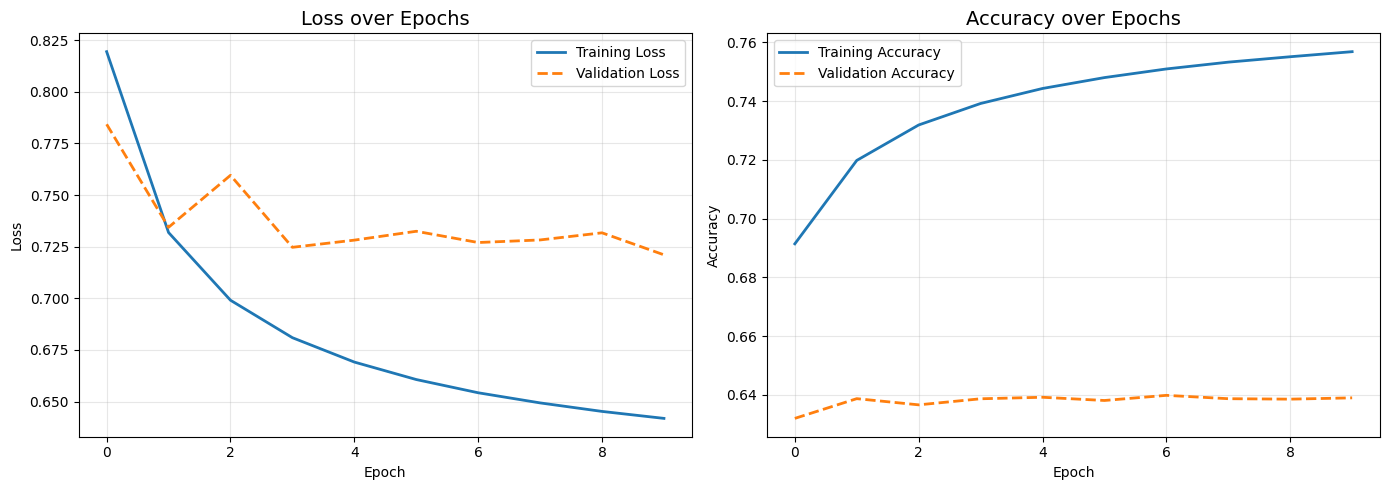

In [56]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['loss'],     label='Training Loss',   linewidth=2)
ax1.plot(history.history['val_loss'], label='Validation Loss', linewidth=2, linestyle='--')
ax1.set_title('Loss over Epochs', fontsize=14)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history.history['accuracy'],     label='Training Accuracy',   linewidth=2)
ax2.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2, linestyle='--')
ax2.set_title('Accuracy over Epochs', fontsize=14)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## PART 8 — Extract Product Embeddings


In [57]:
df_all_products = df_dataset[['product_id', 'product_title']].drop_duplicates().reset_index(drop=True)

df_all_products['pid'] = range(len(df_all_products))

print(f"Unique products to embed: {len(df_all_products):,}")


product_tower_model = Model(
    inputs=input_product,
    outputs=model.get_layer('normalize_product').output,
    name='product_tower'
)


all_product_sequences = tokenize_and_pad(
    df_all_products['product_title'].tolist(),
    MAX_PRODUCT_LEN
)

print(f"Product sequences shape: {all_product_sequences.shape}")


product_embeddings = product_tower_model.predict(all_product_sequences, batch_size=512, verbose=1)

print(f"\nProduct embeddings shape: {product_embeddings.shape}")
print("Each product is now represented as a 16-dimensional vector")


Unique products to embed: 1,814,675
Product sequences shape: (1814675, 30)
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step

Product embeddings shape: (1814675, 16)
Each product is now represented as a 16-dimensional vector


In [58]:
embedding_column_names = [f'dim_{i}' for i in range(OUTPUT_DIM)]

df_product_embeddings = pd.DataFrame(product_embeddings, columns=embedding_column_names)

df_product_embeddings['product_id']    = df_all_products['product_id'].values
df_product_embeddings['product_title'] = df_all_products['product_title'].values
df_product_embeddings['pid']           = df_all_products['pid'].values

print("Product embedding table:")
df_product_embeddings.head()


Product embedding table:


,dim_0,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,dim_7,dim_8,dim_9,dim_10,dim_11,dim_12,dim_13,dim_14,dim_15,product_id,product_title,pid
0,0.537093,0.222689,-0.417659,-0.091408,-0.332142,0.207902,-0.131192,-0.249060,-0.298325,0.260036,-0.081940,-0.161373,-0.151820,-0.087007,-0.162339,-0.004207,B000MOO21W,Panasonic FV-20VQ3 WhisperCeiling 190 CFM Ceiling Mounted Fan,0
1,0.262674,0.039084,-0.499146,0.059652,-0.478030,0.358065,-0.109708,-0.262201,-0.035780,0.287617,-0.234761,-0.192592,0.185444,0.013444,0.031776,-0.165752,B07X3Y6B1V,"Homewerks 7141-80 Bathroom Fan Integrated LED Light Ceiling Mount Exhaust Ventilation, 1.1 Sones, 80 CFM",1
2,0.235440,0.103806,-0.538751,0.007686,-0.463871,0.332492,-0.147191,-0.248248,0.001574,0.298966,-0.260593,-0.187455,0.118873,0.073740,0.029657,-0.146904,B07WDM7MQQ,"Homewerks 7140-80 Bathroom Fan Ceiling Mount Exhaust Ventilation, 1.5 Sones, 80 CFM, White",2
3,0.076516,-0.084866,-0.177325,0.112121,-0.223362,0.276754,-0.364074,-0.148808,-0.183317,0.330266,-0.220201,-0.342402,-0.011545,-0.338924,0.154128,-0.463232,B07RH6Z8KW,Delta Electronics RAD80L BreezRadiance 80 CFM Heater/Fan/Light Combo White (Renewed),3
4,0.272350,0.161943,-0.473878,-0.027453,-0.429480,0.359034,-0.277131,-0.040789,0.021688,0.348018,-0.144254,-0.147360,0.044855,-0.208454,0.031093,-0.268176,B07QJ7WYFQ,Panasonic FV-08VRE2 Ventilation Fan with Recessed LED (Renewed),4


## PART 9 — Build the Product Search Index (FAISS)


In [59]:
product_search_index = faiss.IndexFlatIP(OUTPUT_DIM)

index_to_pid = df_product_embeddings['pid'].tolist()

index_to_pid_as_ints = []
for x in index_to_pid:
    index_to_pid_as_ints.append(int(x))

with open('index_to_pid.json', 'w') as f:
    json.dump(index_to_pid_as_ints, f)
print("Saved: index_to_pid.json")

pid_to_title      = {}
pid_to_product_id = {}

for _, row in df_product_embeddings.iterrows():
    pid = int(row['pid'])
    pid_to_title[pid]      = row['product_title']
    pid_to_product_id[pid] = row['product_id']

vectors = df_product_embeddings[embedding_column_names].values.astype('float32')

faiss.normalize_L2(vectors)

product_search_index.add(vectors)
print(f"Added {product_search_index.ntotal:,} product vectors to FAISS index")

faiss.write_index(product_search_index, 'product_search_index.faiss')
print("Saved: product_search_index.faiss")

product_search_index = faiss.read_index('product_search_index.faiss')
print("FAISS product search index ready!")


Saved: index_to_pid.json
Added 1,814,675 product vectors to FAISS index
Saved: product_search_index.faiss
FAISS product search index ready!


## PART 10 — Quality Check: Are Similar Products Close Together?


In [60]:

TOP_K         = 5
ROWS_TO_CHECK = 10

results = []

for i in range(ROWS_TO_CHECK):
    row = df_product_embeddings.iloc[i]
    pid           = int(row.pid)
    product_title = row.product_title

    raw_vec = df_product_embeddings[embedding_column_names].iloc[i].values
    vec = raw_vec.astype('float32').reshape(1, -1)

    faiss.normalize_L2(vec)

    _, neighbor_index_array = product_search_index.search(vec, TOP_K + 1)
    neighbor_indices = neighbor_index_array[0]

    nearest_titles = []
    for faiss_row_idx in neighbor_indices:
        if faiss_row_idx == -1:
            continue

        real_pid = int(index_to_pid[faiss_row_idx])

        if real_pid == pid:
            continue

        nearest_titles.append(pid_to_title.get(real_pid, 'UNKNOWN'))

        if len(nearest_titles) == TOP_K:
            break

    results.append([product_title] + nearest_titles)

columns = ['product']
for i in range(TOP_K):
    columns.append(f'similar_{i+1}')

df_quality_check = pd.DataFrame(results, columns=columns)

print("Product similarity quality check:")
print("(Each row shows a product and its 5 most similar products)")
display(df_quality_check)


Product similarity quality check:
(Each row shows a product and its 5 most similar products)


,product,similar_1,similar_2,similar_3,similar_4,similar_5
0,Panasonic FV-20VQ3 WhisperCeiling 190 CFM Ceiling Mounted Fan,Panasonic FV-40VQ4 WhisperCeiling 380 CFM Ceiling Mounted Fan,AGTEK Landscape Fabric 4x8 FT Heavy Duty Ground Cover Pack of 2,Balay 3EB715XR - Placa vitrocerámica,Balay 3EB720XR - Placa vitrocerámica,"Infinity Collection Soccer Gifts, Soccer Charm Bracelet, Soccer Jewelry, Adjustable Soccer Charm Bracelet for Soccer Players, Soccer Gift"
1,"Homewerks 7141-80 Bathroom Fan Integrated LED Light Ceiling Mount Exhaust Ventilation, 1.1 Sones, 80 CFM","Homewerks 7140-80 Bathroom Fan Ceiling Mount Exhaust Ventilation, 1.5 Sones, 80 CFM, White","Homewerks 7107-03HW Bathroom Fan Ceiling Mount Exhaust Ventilation 1.0 Sones, 110 CFM, Energy Star, White","Homewerks 7117-01-BN Bathroom Integrated LED Light Ceiling Mount Exhaust Ventilation 1.1 Sones 80 CFM, Bath Fan Brushed Nickel","Homewerks 7140-50 Bathroom Fan Ceiling Mount Exhaust Ventilation, 1.5 Sones, 50 CFM, White","Homewerks 7141-50 Bathroom Fan Integrated LED Light Ceiling Mount Exhaust Ventilation, 0.7 Sones, 50 CFM"
2,"Homewerks 7140-80 Bathroom Fan Ceiling Mount Exhaust Ventilation, 1.5 Sones, 80 CFM, White","Homewerks 7107-03HW Bathroom Fan Ceiling Mount Exhaust Ventilation 1.0 Sones, 110 CFM, Energy Star, White","Homewerks 7141-80 Bathroom Fan Integrated LED Light Ceiling Mount Exhaust Ventilation, 1.1 Sones, 80 CFM","Homewerks 7140-50 Bathroom Fan Ceiling Mount Exhaust Ventilation, 1.5 Sones, 50 CFM, White","Homewerks 7117-01-BN Bathroom Integrated LED Light Ceiling Mount Exhaust Ventilation 1.1 Sones 80 CFM, Bath Fan Brushed Nickel",Disney Mickey Mouse Baby Boys Layette Set Bodysuit Pants Hat Bib 0-3 Months
3,Delta Electronics RAD80L BreezRadiance 80 CFM Heater/Fan/Light Combo White (Renewed),"Skytech 9800326 SKY-5301P Programmable Backlit Fireplace Remote Control with Thermostat, LCD Touch Screen",Skytech 9800325 SKY-3301P2 Backlit Programmable Fireplace Remote Control with Thermostat,"HITOP 50W 100W 300W Adjustable Aquarium Heater, Submersible Fish Tank Heater Thermostat with Suction Cups (100W-grey)","ARCTIC F9 Silent - 92 mm Case Fan, Extra quiet motor, Computer, Almost inaudible, Push- or Pull Configuration, Fan Speed: 1000 RPM - Black/White",Baseboard Heater Thermostat Temperature Control Knob Marley Fahrenheat Dayton Qmark Berko
4,Panasonic FV-08VRE2 Ventilation Fan with Recessed LED (Renewed),Panasonic FV-08VRE2 Ventilation Fan with Recessed LED,NIKE Little Boys' 2-Piece Tracksuit (Sizes 4-7),"Nike Hypervenom Phinish II AG, Zapatillas de Fútbol Unisex Niños, Verde (Elctrc Green/Black-Hyper Orange-Volt), 33 EU","Panasonic FV-0511VQ1 WhisperCeiling DC Ventilation Fan, Speed Selector, SmartFlow Technology, Quiet,White","KAZE APPLIANCE Quiet Bathroom Ventilation Exhaust Fan with LED Light (290 CFM, 4 Sone)"
5,"Panasonic FV-0511VQ1 WhisperCeiling DC Ventilation Fan, Speed Selector, SmartFlow Technology, Quiet,White",Panasonic FV-08VRE2 Ventilation Fan with Recessed LED (Renewed),"Hamilton Beach Programmable Coffee Maker with Built-in Auto-Rinsing Beans Grinder and Thermal Carafe, 10 Cups, Stainless Steel (45501)",Panasonic FV-08VRE2 Ventilation Fan with Recessed LED,"2020 Latest ELUK OMEN Obelisk Gaming Desktop PC (Liquid Cooled Intel i9-9900K CPU, NVIDIA RTX 2080 Ti 11GB GPU, Z390 Mobo, 750 Watt Platinum PSU, Windows 10 Pro, 512GB NVMe SSD + 2TB HDD, 16GB RAM)","Cellucor Super HD Thermogenic Fat Burner Weight Loss Supplement, Appetite Suppressant, & Energy Booster Capsimax, Green Tea Extract, 160mg Caffeine & More 60 Capsules (Packaging May Vary)"
6,"Panasonic FV-0510VSL1 WhisperValue DC Ventilation Fan with Light, 50-80-100 CFM","Panasonic FV-0510VS1 WhisperValue DC Ventilation Fan, 50-80-100 CFM","Panasonic FV-0810VSS1 WhisperValue DC Ventilation Fan, 80 or 100 CFM","Panasonic FV-0511VQCL1 WhisperSense DC Ventilation Fan with Light, 50-80-110 CFM","Panasonic FV-0510VSC1 WhisperValue DC Ventilation Fan with Built-in Condensation Sensor, 50-80-100 C

## PART 11 — Create a Query Tower Sub-Model


In [61]:
query_tower_model = Model(
    inputs=input_query,
    outputs=model.get_layer('normalize_query').output,
    name='query_tower'
)

print("Query Tower sub-model ready!")
query_tower_model.summary()


Query Tower sub-model ready!


Model: "query_tower"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_query (InputLayer)        │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embed_query (Embedding)         │ (None, 10, 64)         │     3,200,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_query                      │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_query (Dense)             │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalize_query (Lambda)        │ (None, 16)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,201,040 (12.21 MB)

 Trainable params: 3,201,040 (12.21 MB)

 Non-trainable params: 0 (0.00 B)

## PART 12 — Search Function


In [62]:
def search(query_text, top_k=10):

    word_id_list  = tokenizer.texts_to_sequences([query_text])
    padded_query  = pad_sequences(
        word_id_list,
        maxlen=MAX_QUERY_LEN,
        padding='post',
        truncating='post'
    )

    query_embedding = query_tower_model.predict(padded_query, verbose=0)[0]

    query_vec_f32 = query_embedding.reshape(1, -1).astype('float32')

    faiss.normalize_L2(query_vec_f32)

    distances_array, row_indices_array = product_search_index.search(query_vec_f32, top_k)

    distances  = distances_array[0]
    faiss_rows = row_indices_array[0]

    results = []
    rank = 1

    total_results = len(faiss_rows)

    for i in range(total_results):

        faiss_row  = faiss_rows[i]
        similarity = distances[i]

        if faiss_row == -1:
            continue

        real_pid = int(index_to_pid[faiss_row])

        title = pid_to_title.get(real_pid, 'UNKNOWN')

        similarity_rounded = round(float(similarity), 4)

        one_result = {
            'rank'            : rank,
            'product_title'   : title,
            'similarity_score': similarity_rounded
        }

        results.append(one_result)

        rank = rank + 1

    return pd.DataFrame(results)


print("Search function is ready!")
print("Usage: search('your query here', top_k=10)")


Search function is ready!
Usage: search('your query here', top_k=10)


## PART 13 — Run Searches!


In [63]:
test_queries = [
    "red dress for a wedding",
    "best laptop under 1000",
    "nike running shoes for women",
    "bluetooth earbuds under 50",
    "organic skincare products",
    "gaming laptop with rtx graphics",
    "winter jacket for men",
    "coffee maker"
]

TOP_K = 5

for query in test_queries:
    print(f"\n{'='*60}")
    print(f"Query: '{query}'")
    print(f"{'='*60}")
    results_df = search(query, top_k=TOP_K)
    display(results_df)



Query: 'red dress for a wedding'


,rank,product_title,similarity_score
0,1,"Rural Nursing, Fifth Edition: Concepts, Theory, and Practice",0.9200
1,2,Milka (1) Bag Oreo Chocolate Candy Bar - Fun Size - Valentine's Day - Oreo Cookie In Smooth Creme With Chocolate Candy Coating,0.9142
2,3,"La Penosa Història (feat. Victor Alexandre, Ramon Peris) [De la Lluita del Mega Zero Contra la Supermà]",0.8750
3,4,マイクロソフト Surface Pro 7 タイプカバー同梱［Surface Pro7 ノートパソコン］ / 12.3インチ /第10世代 Core-i3 / 4GB / 128GB / プラチナ （ブラックタイプカバー同梱） QWT-00006,0.8677
4,5,L'Anell de Ferro (Ramon Llull),0.8653



Query: 'best laptop under 1000'


,rank,product_title,similarity_score
0,1,"Char-Griller E1224 Smokin Pro 830 Square Inch Charcoal Grill with Side Fire Box, 50 Inch, Black",0.9855
1,2,グラムスタイル カーペット ラグ ラグマット 洗える 低反発 撥水 1.5畳 130×190cm グレー (スーパームートプラス シャドウ),0.9854
2,3,"ZenStyle Height Adjustable Cool Bar Rattan Style Outdoor Patio Table Cooler All-Weather Wicker Bar Table with Ice Bucket for Party, Pool, Deck, Backyard (Brown)",0.9845
3,4,"Smead Two-Pocket Heavyweight File Folder, Letter Size, Assorted Colors, 50 per Carton (87863)",0.9843
4,5,"Outdoor PE Wicker Coffee Table - Patio Rattan Garden Side End Tea Table with Glass Top Furniture, Black",0.9842



Query: 'nike running shoes for women'


...

,rank,product_title,similarity_score
0,1,"ZOTAC Gaming GeForce GTX 1650 OC 4GB GDDR5 128-Bit Gaming Graphics Card, Super Compact, ZT-T16500F-10L",0.9150
1,2,"NETVUE Cámara Vigilancia WiFi Exterior 2K 3MP , Cámara IP Exterior Resistente al Agua IP66, Camara Vigilancia Exterior Detección de Movimiento & Visión Nocturna,Compatible con Alexa",0.8955
2,3,"Poseidon Estuche Perfume Hombre King, Estándar, Único",0.8950
3,4,"Razer Blade 15 Base Gaming Laptop 2020: Intel Core i7-10750H 6-Core, NVIDIA GeForce RTX 2070 Max-Q,15.6"" 4K OLED,16GB RAM,512GB SSD, CNC Aluminum,Chroma RGB,Thunderbolt 3,Creator Ready, Mercury White",0.8938
4,5,"Razer Blade 15 Base Gaming Laptop 2020: Intel Core i7-10750H 6-Core, NVIDIA GeForce RTX 2070 Max-Q, 15.6"" 4K OLED, 16GB RAM, 512GB SSD, CNC Aluminum, Chroma RGB, Thunderbolt 3, Creator Ready, Black",0.8938



Query: 'winter jacket for men'


,rank,product_title,similarity_score
0,1,Wantdo Women's Interchange Winter Jacket Wind Block Anorak Insulated Ski Coat Hoodie Black S,0.9796
1,2,"PUREMSX Men's Plus Size Quilted Parka Jacket Casual Heavyweight Warm Arctic Cloth Quilted Anorak Coat with Tan Faux Fur-Trimmed Hood for Winter Puffer Jacket Winter Classy Coats,Black,XX-Large",0.9718
2,3,Wantdo Women's Interchange Skiing Jacket 3 in 1 Winter Snow Coat Wind Block Anorak Black M,0.9712
3,4,Wantdo Men's Mountain Jacket Wind Resistant Parka Anorak Casual Wear Grey L,0.9680
4,5,Wantdo Women's Winter Coats Light Weight Puffy Jacket with Bag Oiled Green M,0.9674



Query: 'coffee maker'


,rank,product_title,similarity_score
0,1,Sterling Silver Chakra Charm Necklace,0.9825
1,2,"Thermal Coffee Carafe Stainless Steel - Heavy Duty, 24hr Lab Tested Heat Retention, 2 Liter 68oz Insulated Coffee Thermos, Water & Beverage Dispenser, Premium Grade Thermal Pot by Pykal",0.9819
2,3,"Balt 27508 Mobile Floor Lectern, Mahogany 46""H x 25""W x 20.13""D",0.9813
3,4,6 Pieces Summer Waist Bead Chains Colorful Waist Belly Beads African Body Chains Bikini Jewelry for Women and Girls,0.9813
4,5,Sterling Silver Necklace For Women With Disco Beads,0.9811


## PART 14 — Save Everything for Later Use


In [64]:
import json

tokenizer_as_json = tokenizer.to_json()
with open('tokenizer_config.json', 'w') as f:
    f.write(tokenizer_as_json)
print("Saved: tokenizer_config.json")


query_tower_model.save('query_tower.h5')
print("Saved: query_tower.h5")


product_tower_model.save('product_tower.h5')
print("Saved: product_tower.h5")


df_all_products.to_csv('product_metadata.csv', index=False)
print("Saved: product_metadata.csv")


print("\nAll files saved! To use this system later:")
print("1. Load tokenizer from tokenizer_config.json")
print("2. Load query_tower.h5")
print("3. Load product_search_index.faiss")
print("4. Load product_metadata.csv for title lookups")
print("5. Call search(query_text) to search!")


Saved: tokenizer_config.json
Saved: query_tower.h5
Saved: product_tower.h5
Saved: product_metadata.csv

All files saved! To use this system later:
1. Load tokenizer from tokenizer_config.json
2. Load query_tower.h5
3. Load product_search_index.faiss
4. Load product_metadata.csv for title lookups
5. Call search(query_text) to search!


## Summary — Full System Flow

---

Here's the complete picture:

```
TRAINING TIME:

Raw query text  ──►  Tokenizer  ──►  [45, 231, 0, ...]  ──►  Query Tower  ──►  [0.2, -0.5, ...]  (16D)
                                                                                                        \
                                                                                             Cosine Sim  ──►  Match score (0 to 1)
                                                                                                        /
Raw product text ──►  Tokenizer  ──►  [12, 88, 44, ...]  ──►  Product Tower ──►  [0.3, -0.4, ...]  (16D)

Match score = (cosine similarity + 1) / 2
Loss compares this score with the true label (1=relevant, 0=not relevant)
Optimizer adjusts weights to reduce loss


SEARCH TIME:

New query text ──►  Tokenizer  ──►  Query Tower  ──►  16D vector
                                                            |
                                                    FAISS Index Search
                                                            |
                                               Top-K nearest product vectors
                                                            |
                                                   Return product titles ✅
```

| Part | What it does |
|------|--------------|
| 1 | Import libraries |
| 2 | Load and merge data |
| 3 | Convert labels to binary, split train/val |
| 4 | **Tokenize raw text** (word → integer ID, pad to fixed length) |
| 5 | **Build Two-Tower model** (Embedding → Pool → Dense → Normalize → Cosine Similarity → Match Score) |
| 6 | Train the model |
| 7 | Plot training history |
| 8 | Extract 16-dim embeddings for all products |
| 9 | Build FAISS search index from product embeddings |
| 10 | Quality check: are similar products near each other? |
| 11 | Create Query Tower sub-model |
| 12 | `search()` function |
| 13 | Run test searches |
| 14 | Save everything |


## Limitations and Next Steps

## Limitations

1. **Retrieval quality.** Several test queries return incorrect product types (e.g., "coffee maker" returns a microwave). The model was trained only on ESCI labeled pairs, where all products were already candidates for the query. It was not exposed to random products, so unrelated items are not well separated in the embedding space.

2. **Model performance.** Best validation accuracy was 63.9%, compared with 61.6% for always predicting "relevant."

3. **Data merge.** Products were merged on `product_id` only, which included Spanish and Japanese listings and increased the vocabulary to 1.16M words.

4. **Evaluation.** No retrieval metric (e.g., Recall@K) was computed.

## Next Steps

1. Filter to US listings and merge on `product_id` and `product_locale`.
2. Train with in-batch negatives and a softmax loss, so each query is scored against all products in the batch.
3. Evaluate with Recall@10 on the test split.